# What is the optimal number of clusters for K-means?

Source of inspiration: [Lecture №8](https://drive.google.com/file/d/1DEFiFkuUlF9em48vUJYmRRgFAfIXS3xZ/view)

Source of previous implementation:
* https://github.com/BogdanPinchuk/DataScience-PBY_HW18
* https://github.com/BogdanPinchuk/ComputerVision-PBY_HW5

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
    "kneed",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# Load data

from pathlib import Path

import cv2

import apps.reporter as rpt

# Input data
file_name = "resources/images/kodim15.png"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

# Convert it to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")


Attribute,Result
"(rows, cols, channels)","(512, 768, 3)"


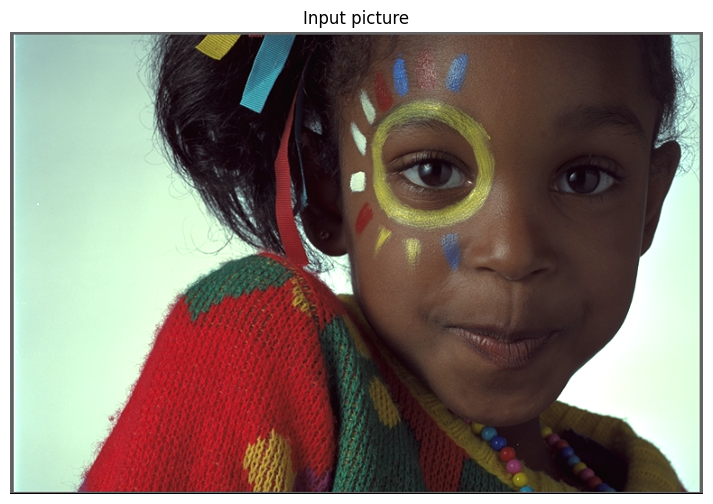

In [3]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data = img_rgb

# Solution
_, ax = plt.subplots(figsize=(9, 6))

ax.imshow(data)
ax.axis(False)

# Plot it
plt.title("Input picture")
plt.show()


In [4]:
# K-means

import numpy as np
import apps.main as mn
from sklearn.cluster import KMeans
from joblib import Parallel, delayed
from sklearn.metrics import mean_squared_error, silhouette_score

# Input data
rng_seed = 42
n_max_clusters = 20
img_in_line = img_rgb.reshape(-1, 3)
img_rgb_float = img_rgb.copy().astype(np.float32)
rows, cols, channels = img_rgb_float.shape


# Solution
def calc_k_means(k: int, data: np.ndarray, rng_seed: int) -> tuple[int, float, np.ndarray, float]:
    """
    Calculation K-means
    :param k: n clusters
    :param data: input data
    :param rng_seed: random seed
    :return: list of tuples (k, inertia)
    """
    kmeans = KMeans(
        n_clusters=k,  # number of necessary clusters
        init="k-means++",  # smart start choosing of the cluster center
        random_state=rng_seed,  # install the seed to get the same results each time
        n_init=10,  # repeat 10 times and take the best result
    )
    kmeans.fit(data)
    clustered_colors = np.asarray(kmeans.cluster_centers_).clip(0, 255).astype(np.uint8)

    # Silhouette Score
    # Note. Commit if it takes a very long time
    if k > 1:
        labels = kmeans.labels_
        score = silhouette_score(data, labels)
    else:
        score = 0.0

    kmeans_quantized = np.zeros_like(img_rgb_float)
    for r in range(rows):
        for c in range(cols):
            # Extract the pixel value, including the error diffused from the neighbours
            pixel = img_rgb_float[r, c, :]

            # Find the closest colour from the palette
            new_pixel = mn.closest_color(pixel, clustered_colors)
            kmeans_quantized[r, c, :] = new_pixel.copy()

    changed_flat = kmeans_quantized.reshape(-1, 3)

    max_value = 255
    # Mean Squared Error
    mse = mean_squared_error(data, changed_flat)
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    # Peak Signal-To-Noise Ratio
    psnr = 20 * np.log10(max_value / rmse)

    kmeans_quantized = np.clip(kmeans_quantized, 0, 255).astype(np.uint8)

    return int(k), float(psnr), kmeans_quantized, float(score)


k_means_list = Parallel(n_jobs=-1)(
    delayed(calc_k_means)(k, img_in_line, rng_seed)
    for k in range(1, n_max_clusters + 1)
)

ks, psnrs, quantized_images, scores = zip(*k_means_list)
wcss = dict(zip(ks, psnrs))
silhouette_scores = dict(zip(ks, scores))

# Print results

KeyboardInterrupt: 

## The Elbow Method

In [ ]:
# The Elbow Method

import numpy as np
import apps.main as mn
import apps.reporter as rpt

# Input data

# Solution
x_data = np.asarray(list(wcss.keys()))
y_data = np.asarray(list(wcss.values()))

norm_coef_curv = mn.calc_curvature_coef(x_data, y_data, normalize=True)
idx = np.argmax(np.abs(norm_coef_curv))
best_k = x_data[idx]
quantized_image = quantized_images[idx]

rp = rpt.Reporter()
rp.add_item("Optimal number of clusters", str(best_k))

# Print results
rp.print_pd_report("The Elbow Method")

images_dict = {
    "Original image": img_rgb,
    f"Quantization K-Means, k={best_k}": quantized_image,
}


In [ ]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
fig, axes = plt.subplots(figsize=(6, 5))

ax_l = axes
ax_l.plot(wcss.keys(), wcss.values(), marker='o', label='PSNR', color='tab:blue')
ax_l.axvline(best_k, linestyle=':', color='red', linewidth=2.0, label=f"best k = {best_k}")

ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax_l.set_title("The Elbow Method", pad=10, loc='center', color='black')
ax_l.set_xlabel("Number of clusters", labelpad=10, loc='center', color='black')
ax_l.set_ylabel("PSNR, dB", labelpad=10, loc='center', color='black')

ax_r = ax_l.twinx()
ax_r.plot(wcss.keys(), norm_coef_curv, marker='o', label='CC', color='tab:orange')
ax_r.set_ylabel("Curvature Coefficient", labelpad=10, loc='center', color='black')

# plt.suptitle("test")

fig.legend(bbox_to_anchor=(0.9, 0.85))
plt.tight_layout()
plt.show()

In [ ]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 2
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Input data")
plt.tight_layout()
plt.show()


[Кривина кривої](https://uk.wikipedia.org/wiki/Кривина_(математика)):
$$k = \frac{{d}x \cdot {d}^2y - {d}y \cdot {d}^2x}{\left(({dx})^2 + ({dy})^2\right)^{3/2}}$$
Radius of curvature:
$$r = \frac{1}{|k|}$$
* If $k > 0$, the curve is concave (or concave upward);
* If $k < 0$, the curve is convex (or concave downward);

**Conclusion.** The "elbow" is located at the inflection point where the graph transitions from a steep decline to a smooth plateau. Visually, this is identified as the point where the graph's curve exhibits the maximum curvature (the smallest radius of curvature). The curvature coefficient is a value inversely proportional to the radius of curvature; thus, the largest coefficient indicates the smallest radius. Since the "elbow" principle is applied visually on scaled axes rather than on the true magnitude of values, we must normalize the axes to a uniform scale before computing the curvature of the graph (rather than the raw data). Consequently, we can determine which point corresponds to the maximum curvature coefficient, and this point will represent the optimal number of clusters. In doing so, it is necessary to analyze the maximum absolute value of the curvature coefficients.

## Kneed algorithm

In [ ]:
# Kneed algorithm

import apps.reporter as rpt
from kneed import KneeLocator

# Input data

# Solution
kneedle = KneeLocator(
    list(wcss.keys()),
    list(wcss.values()),
    curve='concave',
    direction='increasing'
)

best_k_kneedle = kneedle.elbow

rp = rpt.Reporter()
rp.add_item("Optimal number of clusters", str(best_k_kneedle))

# Print results
rp.print_pd_report("Kneedle algorithm")

In [ ]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
fig, axes = plt.subplots(figsize=(6, 5))

ax = axes
ax.plot(wcss.keys(), wcss.values(), marker='o', label='PSNR', color='tab:blue')
ax.axvline(best_k_kneedle, linestyle=':', color='red', linewidth=2.0, label=f"optimal k = {best_k_kneedle}")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Kneed algorithm", pad=10, loc='center', color='black')
ax.set_xlabel("Number of clusters", labelpad=10, loc='center', color='black')
ax.set_ylabel("PSNR, dB", labelpad=10, loc='center', color='black')

# plt.suptitle("test")

fig.legend(bbox_to_anchor=(0.95, 0.8))
plt.tight_layout()
plt.show()

**Conclusion.** The kneed algorithm is highly sensitive to the specified parameters, where `curve='convex'` indicates a curve that is convex downward (resembling a bowl) and `curve='concave'` indicates a curve that is concave upward (resembling a dome), while `direction='decreasing'` signifies a declining trajectory and `direction='increasing'` represents an ascending trajectory. The algorithm normalizes the axes and defines a straight line connecting the two extreme points of the curve. It then drops perpendicular lines from all intermediate points to this baseline and measures their lengths. The point corresponding to the maximum perpendicular distance is determined to be the optimal knee (or elbow) point.

## Silhouette algorithm

In [ ]:
# Silhouette Score

import numpy as np
import apps.reporter as rpt

# Input data

# Solution
x_data = np.asarray(list(silhouette_scores.keys()))
y_data = np.asarray(list(silhouette_scores.values()))

idx = np.argmax(y_data)
best_k_silhouette = x_data[idx]

rp = rpt.Reporter()
rp.add_item("Optimal number of clusters", str(best_k_silhouette))

# Print results
rp.print_pd_report("Silhouette Score approach")